# PPO Training Example on ImprovedB747Env

This notebook demonstrates training a PPO agent from `tensoraerospace/agent/ppo/model.py` on the `ImprovedB747Env` environment from `tensoraerospace/envs/b747.py`.

Features:
- Continuous actions with a Gaussian policy
- Clipped surrogate objective for stable updates
- tqdm progress bar and TensorBoard logging (losses, policy stats, reward)
- Checkpointing with optional gradient saving for resuming training

In [1]:
# Optional installs (run if needed)
# %pip install tensorboard tqdm --quiet

import os
import numpy as np
import torch

from tensoraerospace.envs.b747 import ImprovedB747Env
from tensoraerospace.agent.ppo.model import PPO

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", DEVICE)

# Reproducibility
np.random.seed(1)
_ = torch.manual_seed(1)


Using device: mps


In [ ]:
# Build environment
from tensoraerospace.signals.standard import sinusoid_vertical_shift
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

# Time base
dt = 0.1
_tp = generate_time_period(tn=20, dt=dt)
tps = convert_tp_to_sec_tp(_tp, dt=dt)
number_time_steps = len(_tp)

# Reference theta (radians)
reference_signals = np.reshape(
    sinusoid_vertical_shift(
        tp=np.asarray(tps),
        frequency=0.05/dt,
        amplitude=np.deg2rad(1.0),
        vertical_shift=0.0,
    ),
    [1, -1],
)

# Initial state [u, w, q, theta] (SI units; angles in rad)
init_state = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)

# Env
env = ImprovedB747Env(
    initial_state=init_state,
    reference_signal=reference_signals,
    number_time_steps=number_time_steps,
    dt=dt,
    initial_elevator_deg=0.0,
)

obs, info = env.reset()
print("Obs shape:", np.array(obs).shape)
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)


In [ ]:
# Create PPO agent (tuned hyperparams)
# General tips for ImprovedB747Env:
# - Higher gamma (0.99) improves tracking stability
# - Larger rollout_len (2048) collects more diverse trajectories
# - Moderate clip_param (0.2) balances exploration and stability
# - Lower entropy_coef reduces randomness once converged

# Fast preset: make the notebook complete in minutes.
# Set FAST_PRESET=False for full training.
FAST_PRESET = True

max_episodes = 10 if FAST_PRESET else 1000
rollout_len = 512 if FAST_PRESET else 2048
num_epochs = 3 if FAST_PRESET else 10

agent = PPO(
    env=env,
    gamma=0.99,
    max_episodes=max_episodes,
    rollout_len=rollout_len,
    clip_pram=0.2,
    num_epochs=num_epochs,  # Was 64!
    batch_size=64,
    entropy_coef=0.01,  # Increased
    actor_lr=3e-4,  # Decreased
    critic_lr=1e-3,  # Decreased
    gae_lambda=0.95,
    max_grad_norm=0.5,
    target_kl=0.015,  # Enabled!
    normalize_obs=True,
    normalize_reward=False,
    seed=336699,
    device=DEVICE,
)

print("FAST_PRESET:", FAST_PRESET)
print("Actor parameters:", sum(p.numel() for p in agent.actor.parameters()))
print("Critic parameters:", sum(p.numel() for p in agent.critic.parameters()))

In [10]:
# Quick run (short) — optional
# Train the agent for a few episodes
agent.train()


  0%|          | 0/500 [00:00<?, ?it/s]

 10%|█         | 50/500 [00:39<06:15,  1.20it/s]


New best model! Reward: -0.00 (episode 50)


 12%|█▏        | 60/500 [00:47<05:29,  1.34it/s]


New best model! Reward: -0.00 (episode 60)


...

 86%|████████▌ | 430/500 [05:29<00:51,  1.36it/s]


New best model! Reward: -0.00 (episode 430)


 98%|█████████▊| 490/500 [06:14<00:07,  1.34it/s]


New best model! Reward: -0.00 (episode 490)


100%|██████████| 500/500 [06:22<00:00,  1.31it/s]


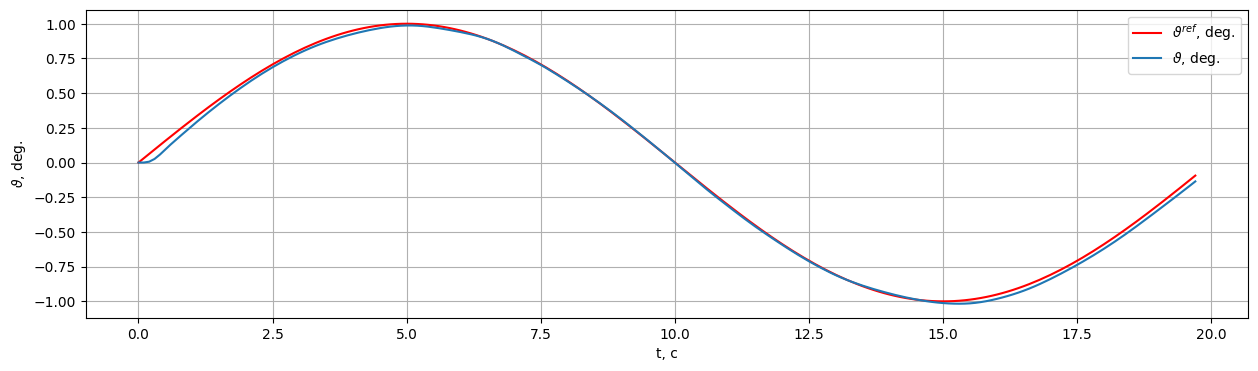

In [11]:
# Plot theta (pitch angle) tracking
env.unwrapped.model.plot_transient_process('theta', tps, reference_signals[0], to_deg=True, figsize=(15,4))

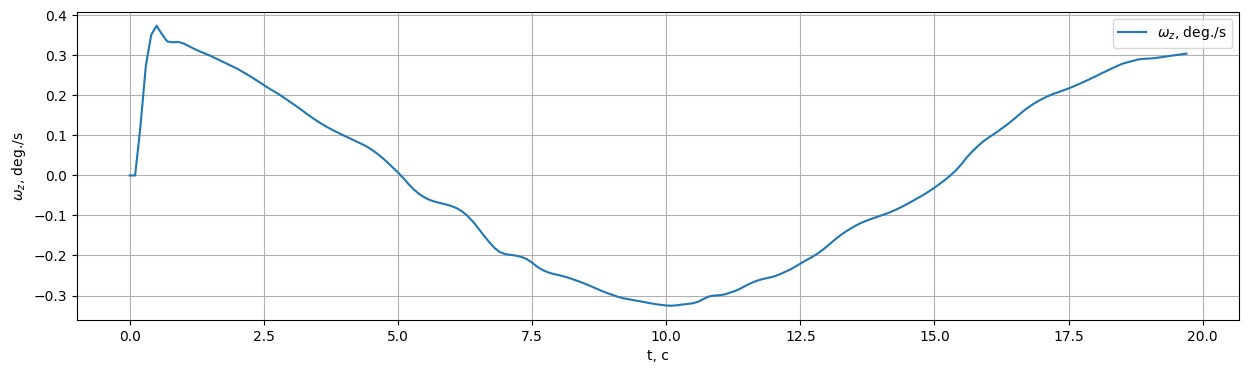

In [12]:
# Plot pitch rate (q)
env.unwrapped.model.plot_state(state_name='q', time=tps, to_deg=True, figsize=(15,4))


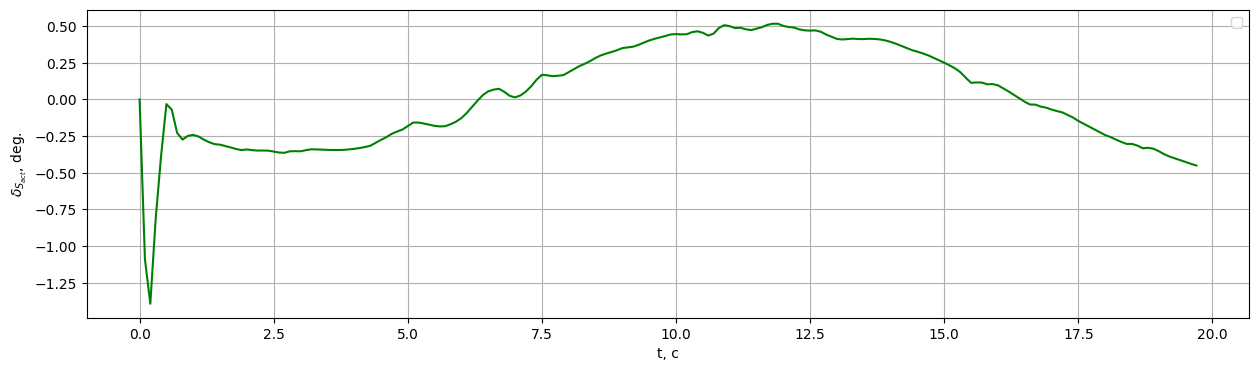

In [13]:
# Plot elevator control
env.unwrapped.model.plot_control(control_name='ele', time=tps, to_deg=True, figsize=(15,4))


In [14]:
agent.save("./ppo_b747_improved")

AttributeError: 'ImprovedB747Env' object has no attribute 'get_init_args'